In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Load significant HGA

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

 16%|█▌        | 276/1711 [00:31<02:42,  8.84it/s]


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [20]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [21]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 1139648
PIC electrode count: 1056000


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,0.021346,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,0.055625,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,0.080085,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,0.117382,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,0.113657,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [ ]:
# delay significant 

delay_mask = (
    (HGAs['phase'] == 'delay') &
    # (HGAs['time'] >= 0.0) &
    # (HGAs['time'] <= 0.5) &
    # (HGAs['mask'] == True) &
    (HGAs['roi'] == 'AIC') &
    (HGAs['description'] == 'Repeat') &
    (HGAs['subject'].isin(subjects))
)

all_channels = list(
    set(HGAs.loc[delay_mask, 'channel'].unique())
)

import re
def split_electrode(name):
    # 匹配格式: SUBJECT_REGIONstart-end
    m = re.match(r'(.+_\D+)(\d+)-(\d+)$', name)
    if m:
        prefix, start, end = m.group(1), m.group(2), m.group(3)
        return [f"{prefix}{start}", f"{prefix}{end}"]
    return [name, name]  # fallback: 无法拆分则返回原名

electrodes = all_channels  # 你的列表
split_electrodes = [split_electrode(e) for e in electrodes]
all_channels = [ch for pair in split_electrodes for ch in pair]
all_channels = np.unique(all_channels)

delay_sig_mask = (
    (HGAs['phase'] == 'delay') &
    (HGAs['time'] >= 0.0) &
    (HGAs['time'] <= 0.5) &
    (HGAs['mask'] == True) &
    (HGAs['roi'] == 'AIC') &
    (HGAs['description'] == 'Repeat') &
    (HGAs['subject'].isin(subjects))
)
sig_channels = list(
    set(HGAs.loc[delay_sig_mask, 'channel'].unique())
)

electrodes = sig_channels  # 你的列表
split_electrodes = [split_electrode(e) for e in electrodes]
sig_channels = [ch for pair in split_electrodes for ch in pair]
sig_channels = np.unique(sig_channels)

print(len(all_channels))
print(len(sig_channels))

129
56


In [34]:
import pandas as pd

df_delay = pd.read_csv('/hpc/home/ns458/coganlab/nanlinshi/insula/delay.csv')
delay_channels = (df_delay['Subject'] + '_' + df_delay['Channel']).tolist()
subjects = list(df_delay.Subject.unique())
# 结果: ['D0029_LAIP8', 'D0030_RAIP1', ...]
all_set = set(all_channels)
delay_set = set(delay_channels)

intersection = all_set & delay_set
print(f"交集: {len(intersection)} 个")
print(sorted(intersection))

交集: 13 个
[np.str_('D0047_LI6'), np.str_('D0079_LFAI2'), np.str_('D0080_LAI6'), np.str_('D0080_LAI7'), np.str_('D0084_RAI5'), np.str_('D0084_RAI6'), np.str_('D0085_RAI2'), np.str_('D0085_RAI4'), np.str_('D0088_LAI5'), np.str_('D0088_LAI6'), np.str_('D0101_RFAI2'), np.str_('D0101_RIA3'), np.str_('D0106_LAI7')]


=== 包含关系检查 ===
sig_channels ⊆ all_channels: True
  sig 中不在 all 里的: set()
delay_channels ⊆ all_channels: True
  delay 中不在 all 里的 (前10): []

all ∩ sig:   56
all ∩ delay: 13
sig ∩ delay: 10
all ∩ sig ∩ delay: 10


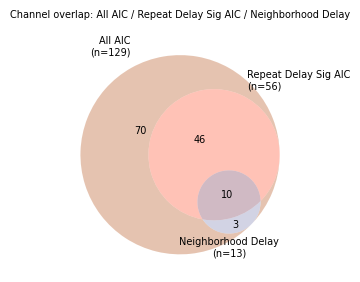

In [49]:
from matplotlib_venn import venn3, venn3_circles

all_set = set(all_channels)
sig_set = set(sig_channels)
delay_set = set(intersection)

# 验证包含关系
print("=== 包含关系检查 ===")
print(f"sig_channels ⊆ all_channels: {sig_set.issubset(all_set)}")
print(f"  sig 中不在 all 里的: {sig_set - all_set}")
print(f"delay_channels ⊆ all_channels: {delay_set.issubset(all_set)}")
print(f"  delay 中不在 all 里的 (前10): {list(delay_set - all_set)[:10]}")
print()
print(f"all ∩ sig:   {len(all_set & sig_set)}")
print(f"all ∩ delay: {len(all_set & delay_set)}")
print(f"sig ∩ delay: {len(sig_set & delay_set)}")
print(f"all ∩ sig ∩ delay: {len(all_set & sig_set & delay_set)}")

fig, ax = plt.subplots(figsize=(8*cm, 8*cm))

v = venn3(
    [all_set, sig_set, delay_set],
    set_labels=('All AIC\n(n={})'.format(len(all_set)),
                'Repeat Delay Sig AIC\n(n={})'.format(len(sig_set)),
                'Neighborhood Delay\n(n={})'.format(len(delay_set))),
    set_colors=(orange, red, blue),
    alpha=0.5,
    ax=ax,
)

for text in ax.texts:
    text.set_fontsize(fontsize)

ax.set_title('Channel overlap: All AIC / Repeat Delay Sig AIC / Neighborhood Delay\n',
             fontsize=fontsize)
plt.tight_layout()
plt.show()

# Temporal dynamic of listen-repeat circuit

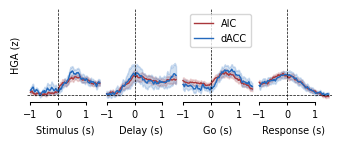

In [6]:
rois = ['AIC', 'dACC']

colors = [red, blue]

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.hemi=='L')
    & (HGAs.subject!='D0007')
    # & (HGAs.roi.isin(rois) | HGAs.label.str.contains('Opercular'))
    & (HGAs.roi.isin(rois))
    & (HGAs.subject!='D0121')
]

phases = ['stimulus', 'delay', 'go' ,'response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5*len(phases)*cm, 3*cm),)

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (ax, phase) in zip(axes, phases):
    
    legend = True if ax == axes[-2] else False
    line1 = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        hue_order=rois,
        ax=ax,
        palette=colors,
        legend=legend,
        lw=1
    )
    
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == axes[-2] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
    if ax != axes[0]:
        # ax.set_xlabel('Time (s)', fontsize=7)
        ax.set_ylabel('', fontsize=7)
    else:
        ax.set_ylabel('HGA (z)', fontsize=7)

# plt.savefig('../img/fig2/fig2_AIPI_temporal_LS_{}.svg'.format('_'.join(rois)), dpi=300, bbox_inches='tight')
plt.show()

# Spatial Distribution of HGA

In [ ]:
phase = 'response'

spatial = subset[
    (subset.phase == phase)
    & (subset.time>0)
    & (subset.time<1)
    ].groupby('channel').agg({
    'value': 'max',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0027_LAI2-3,0.688180,-32.470676,9.175895,4.597974,AIC,ctx_lh_S_circular_insula_sup,response,L,D0027,Repeat,SentenceRep
1,D0027_LAI3-4,0.795839,-30.700923,13.124481,11.623351,AIC,ctx_lh_S_circular_insula_sup,response,L,D0027,Repeat,SentenceRep
2,D0028_LAI1-2,0.587180,-34.700069,8.872246,-13.792580,AIC,ctx_lh_G_insular_short,response,L,D0028,Repeat,SentenceRep
3,D0028_LAI3-4,0.547905,-34.543239,15.001830,0.344973,AIC,ctx_lh_G_insular_short,response,L,D0028,Repeat,SentenceRep
4,D0057_RAI5-6,1.231318,31.937746,11.592552,7.984656,AIC,ctx_rh_S_circular_insula_sup,response,R,D0057,Repeat,SentenceRep


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


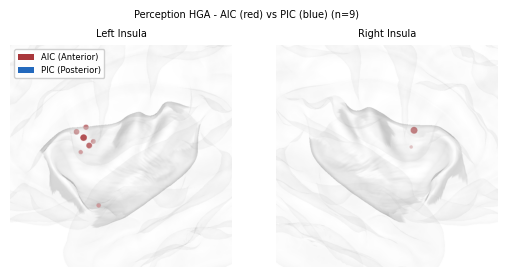

In [ ]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)


for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

# plt.savefig('../img/fig2/fig2_AIPI_spatial_Listen.svg', dpi=300, bbox_inches='tight')

# Lateralization

In [72]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 1373/1373 [02:50<00:00,  8.04it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.107115,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.100700,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.087711,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.077369,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.046683,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [73]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [74]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 903552
PIC electrode count: 838272


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.107115,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.100700,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.087711,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.077369,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.046683,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [ ]:
from scipy.stats import fisher_exact

sub = HGAs[
    (HGAs.description == 'Repeat') &
    (HGAs.modality == 'sound') &
    (HGAs.roi.isin(['AIC', 'PIC']))
]

# 定义每个 phase 的时间窗口
phase_windows = {
    'stimulus': (0, 1.2),
    'response': (-0.5, 0.5),
}

print("=== Incidence Rate by Phase ===\n")
for phase, (t_min, t_max) in phase_windows.items():
    # 筛选该 phase + 时间窗口内的数据
    phase_data = sub[
        (sub.phase == phase) & 
        (sub.time >= t_min) & 
        (sub.time <= t_max)
    ]
    
    # 每个电极在该窗口内是否有任意 mask=True
    sig = (phase_data
        .groupby(['channel', 'roi', 'hemi', 'subject'])['mask']
        .any()
        .reset_index()
        .rename(columns={'mask': 'is_sig'})
    )
    
    print(f"--- {phase.upper()} [{t_min}, {t_max}]s ---")
    print(sig.groupby(['roi', 'hemi']).agg(
        n_sig=('is_sig', 'sum'),
        n_total=('is_sig', 'count'),
        rate=('is_sig', 'mean')
    ).round(3))
    
    for roi in ['AIC', 'PIC']:
        d = sig[sig.roi == roi]
        left  = d[d.hemi == 'L']
        right = d[d.hemi == 'R']
        if left.shape[0] == 0 or right.shape[0] == 0:
            continue
        table = [
            [int(left['is_sig'].sum()),  int((~left['is_sig']).sum())],
            [int(right['is_sig'].sum()), int((~right['is_sig']).sum())],
        ]
        odds, p = fisher_exact(table, alternative='greater')
        print(f"  {roi}: L={table[0][0]}/{left.shape[0]} ({table[0][0]/left.shape[0]:.0%})  "
              f"R={table[1][0]}/{right.shape[0]} ({table[1][0]/right.shape[0]:.0%})  "
              f"OR={odds:.2f}  p={p:.4f}")
    print()

=== Incidence Rate by Phase ===

--- STIMULUS [0, 1.2]s ---
          n_sig  n_total   rate
roi hemi                       
AIC L        24      130  0.185
    R         8       76  0.105
PIC L         6      103  0.058
    R        11       70  0.157
  AIC: L=24/130 (18%)  R=8/76 (11%)  OR=1.92  p=0.0919
  PIC: L=6/103 (6%)  R=11/70 (16%)  OR=0.33  p=0.9915

--- RESPONSE [-0.5, 0.5]s ---
          n_sig  n_total   rate
roi hemi                       
AIC L        43      130  0.331
    R        37       76  0.487
PIC L        42      103  0.408
    R        25       70  0.357
  AIC: L=43/130 (33%)  R=37/76 (49%)  OR=0.52  p=0.9908
  PIC: L=42/103 (41%)  R=25/70 (36%)  OR=1.24  p=0.3050



In [87]:
subset = HGAs[
    (HGAs.roi.isin(['AIC', 'PIC'])) &
    (HGAs.description == 'Repeat') &
    (HGAs.modality == 'sound') &
    (HGAs.phase.isin(['stimulus', 'response']))
]

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


(-1.0, 0.5)

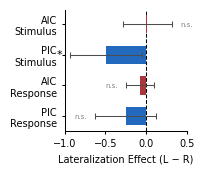

In [89]:
import numpy as np

# 重新跑模型，提取精确的 coefficient 和 CI
coef_key = "C(hemi, Treatment('L'))[T.R]"
plot_data = []

for phase in ['stimulus', 'response']:
    for roi_name, roi_color in [('AIC', red), ('PIC', blue)]:
        roi_data = summary[(summary.phase == phase) & (summary.roi == roi_name)].copy()
        model = smf.mixedlm(
            "peak_value ~ C(hemi, Treatment('L'))", 
            data=roi_data,
            groups=roi_data["subject"]
        )
        fit = model.fit(reml=True)
        coef = fit.params[coef_key]
        se = fit.bse[coef_key]
        pval = fit.pvalues[coef_key]
        ci_low = coef - 1.96 * se   # 95% CI
        ci_high = coef + 1.96 * se
        plot_data.append({
            'label': f"{roi_name}\n{phase.capitalize()}",
            'coef': coef,                        # 取反：变成 L - R
            'ci_lo_dist': abs(ci_high - coef),    # 正距离
            'ci_hi_dist': abs(coef - ci_low),     # 正距离
            'pval': pval,
            'color': roi_color,
        })

# ── 画图 ──
fig, ax = plt.subplots(figsize=(4*cm, 4*cm))
y_pos = np.arange(len(plot_data))

# 画 0 线 (No lateralization)
ax.axvline(0, color='black', linestyle='--', linewidth=0.75, zorder=0)

for i, d in enumerate(plot_data):
    # 用和 barplot 一样的浅色半透明主题风格
    ax.barh(i, d['coef'], 
            xerr=[[d['ci_lo_dist']], [d['ci_hi_dist']]], 
            color=d['color'],
            height=0.6,
            error_kw={
                'ecolor': '#4d4d4d',   # 深灰色的 errorbar，和 seaborn 默认质感类似
                'elinewidth': 0.75,    # 对应你原来的 errwidth=0.75
                'capsize': 2,
                'capthick': 0.75       # 小帽子的粗细也统一
            })
    
    # 显著性标注位置动态计算
    marker = '*' if d['pval'] < 0.05 else 'n.s.'
    
    # 因为现在是 L - R，值为正代表 L > R。
    # 我们把星号放在误差棒靠外的一侧
    if d['coef'] >= 0:
        x_pos = d['coef'] + d['ci_hi_dist'] + 0.1
    else:
        x_pos = d['coef'] - d['ci_lo_dist'] - 0.1
        
    ax.text(x_pos, i, marker, 
            ha='left' if d['coef'] >= 0 else 'right', 
            va='center', 
            fontsize=8 if marker != 'n.s.' else 5,
            color='black' if marker == '*' else 'grey')

ax.set_yticks(y_pos)
ax.set_yticklabels([d['label'] for d in plot_data], fontsize=7)
ax.set_xlabel('Lateralization Effect (L − R)', fontsize=7)
ax.invert_yaxis()
sns.despine()

ax.tick_params(labelsize=7, width=0.75, length=2)
plt.setp(ax.spines.values(), linewidth=0.75)

ax.set_xlim(-1, 0.5)  

# plt.savefig('../img/fig2/fig2_lateralization_coefficient_LMM.svg', dpi=300, bbox_inches='tight')

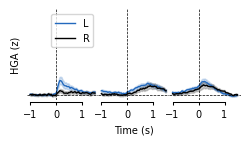

In [94]:
rois = ['AIC','PIC']
colors = [red, 'black']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.roi.isin(rois))
    & (HGAs.subject!='D0121')
]

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(7*cm, 3*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (ax, phase) in zip([ax1, ax2, ax3], ['stimulus', 'go', 'response']):
    
    legend = True if ax == ax1 else False
    line1 = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='hemi',
        ax=ax,
        palette={'L':blue,'R':'black'},
        legend=legend,
        lw=1
    )

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == ax1 and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
ax1.set_xlabel('', fontsize=7)   
ax2.set_xlabel('Time (s)', fontsize=7)   
ax3.set_xlabel('', fontsize=7)   

ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)

plt.savefig(f'../img/fig2/fig2_laterization_temporal_LS_{rois[0]}.svg', dpi=300, bbox_inches='tight')
plt.show()

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 28.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/hpc/home/ns

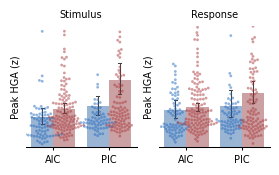

In [95]:
summary = subset.groupby(['channel', 'roi', 'hemi', 'phase', 'subject']).agg(
    peak_value=('value', 'max'),
    mean_value=('value', 'mean')
).reset_index()


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8*cm, 4*cm))

# sns.barplot(
#     data=summary[summary.phase=='stimulus'], 
#     x='roi', 
#     y='peak_value', 
#     hue='hemi'
# )

for (phase, ax) in zip(['stimulus', 'response'], [ax1, ax2]):
    
    sns.swarmplot(data=summary[summary.phase==phase], 
            x="roi", 
            y="peak_value", 
            hue="hemi",
            dodge=True,
            size=2,
            alpha=0.5,
            palette={"L": red, "R": blue}, # 相同颜色
            ax=ax,
            legend=False,)
        
    sns.barplot(data=summary[summary.phase==phase], 
                x="roi", 
                y="peak_value", 
                hue="hemi",
                ax=ax,
                palette={"L": red, "R": blue}, # 相同颜色
                legend=False,
                dodge=0.5,       # 关键：左右错开
            #    scale=0.8,       # 点的大小
                errorbar=('ci', 95), # 显示 95% 置信区间 (或者用 'se' 显示标准误)
                alpha=0.5,
                capsize=0.1,     # 误差棒的小帽子
                errwidth=0.75)



    ax.set_title(f'{phase.capitalize()}', fontsize=7)
    
    ax.set_ylim(0, 1.5)
    ax.set_yticklabels([])
    ax.set_xlabel('', fontsize=7)
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('Peak HGA (z)', fontsize=7)


sns.despine(left=True)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)

plt.savefig('../img/fig2/fig2_lateralized_barplot.svg', dpi=300, bbox_inches='tight')

In [96]:
phase = 'response'

spatial = subset[
    (subset.phase == phase)
    & (subset.time>-0.5)
    & (subset.time<0.5)
    ].groupby('channel').agg({
    'value': 'max',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0007_RFG1-2,0.724627,57.291674,20.558277,-14.696772,AIC,ctx_rh_G_insular_short,response,R,D0007,Repeat,SentenceRep
1,D0022_LPIF3-4,2.310861,-34.587586,-19.677040,-2.311079,PIC,ctx_lh_S_circular_insula_inf,response,L,D0022,Repeat,PhonemeSequence
2,D0022_LPIF4-5,2.699789,-40.742572,-20.437126,-4.055261,PIC,ctx_lh_S_circular_insula_inf,response,L,D0022,Repeat,PhonemeSequence
3,D0023_R2IF1-2,0.483014,33.089530,-8.192050,18.614382,PIC,ctx_rh_S_circular_insula_sup,response,R,D0023,Repeat,LexicalDelay
4,D0023_R2IF2-3,0.484489,36.686262,-8.172090,19.151989,PIC,ctx_rh_S_circular_insula_sup,response,R,D0023,Repeat,LexicalDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


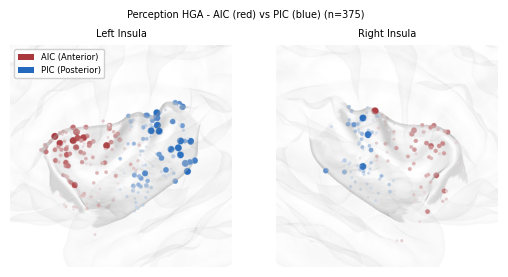

In [97]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)


for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

# plt.savefig('../img/fig2/fig2_AIPI_spatial_lateralized_stimulus.svg', dpi=300, bbox_inches='tight')

# About Timing

In [48]:
import pandas as pd

def get_onset_latency(df):
    """
    Get ONSET latency (first significant time point) in the significant regions.
    Assumes 'mask' column indicates significant clusters.
    """
    results = []
    
    # 按 channel 和 phase 分组
    for (channel, phase, description, task), group in df.groupby(['channel', 'phase', 'description','task']):
        # 1. 只筛选显著的时间点
        sig_data = group[group['mask'] == True]
        
        if len(sig_data) == 0:
            continue
            
        # -------------------------------------------------------
        # 修改核心逻辑：不再找 idxmax (Peak)，而是找最早的时间点 (Onset)
        # -------------------------------------------------------
        
        # 2. 必须按时间排序，确保取到的是起始点
        # 假设你的时间列叫 'time'
        sig_data = sig_data.sort_values('time')
        
        # # 3. 取第一行，这就是 Onset
        onset_row = sig_data.iloc[0]
        
        # peak_idx = sig_data['value'].idxmax()
        # onset_row = sig_data.loc[peak_idx]
        
        
        # 4. (可选) 鲁棒性检查：
        # 有时候 mask 可能是断断续续的（比如 [True, False, True, True...]）
        # 如果你想忽略那种非常短暂的偶然显著（比如只持续了10ms），
        # 你可以在这里加逻辑判断 consecutive points。
        # 但通常如果前面的置换检验做好了 cluster correction，直接取第一个点即可。

        results.append({
            'channel': channel,
            'description': description,
            'task': task,
            'phase': phase,
            'onset_latency': onset_row['time'],      # 这里改名为 onset_latency
            'peak_value': onset_row['value'],        # 记录一下 onset 时的强度，或者你可以保留 max value
            'subject': onset_row['subject'],
            'roi': onset_row['roi'],
            'hemi': onset_row['hemi'],
            'label': onset_row['label'],
            'x': onset_row['x'],
            'y': onset_row['y'],
            'z': onset_row['z'],
        })
    
    return pd.DataFrame(results)

latency = get_onset_latency(HGAs[(HGAs.description=='Repeat') & (HGAs.modality=='sound')])
latency.head()

,channel,description,task,phase,onset_latency,peak_value,subject,roi,hemi,label,x,y,z
0,D0005_LTG13-14,Repeat,SentenceRep,stimulus,0.335938,0.449499,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-67.238742,-17.127162,-3.621204
1,D0005_LTG14-15,Repeat,SentenceRep,response,0.242188,0.291811,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-68.886726,-28.295294,0.243498
2,D0005_LTG14-15,Repeat,SentenceRep,stimulus,0.242188,0.329092,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-68.886726,-28.295294,0.243498
3,D0005_LTG15-16,Repeat,SentenceRep,response,0.250000,0.266283,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-69.639740,-38.151283,4.609248
4,D0005_LTG15-16,Repeat,SentenceRep,stimulus,0.250000,0.242492,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-69.639740,-38.151283,4.609248


In [49]:
# remove entry if stimulus onset_latency is <0
exclude = latency[(latency.phase == 'stimulus') & (latency['onset_latency'] < 0)].index
latency = latency.drop(exclude)

In [46]:
import statsmodels.formula.api as smf

target_rois = ['STG',
               'SMC', 
               'IFG',
               'AIC',
               'PIC',
               ] 


df_model = latency[(latency['roi'].isin(target_rois)) & (latency.phase=='stimulus')].copy()

df_model['onset_latency'] = pd.to_numeric(df_model['onset_latency'], errors='coerce')

model = smf.mixedlm("onset_latency ~ roi*hemi", data=df_model, groups=df_model["subject"])

result = model.fit(method=['nm', 'lbfgs'], maxiter=5000)

print(result.summary())

             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  onset_latency
No. Observations:   465      Method:              REML         
No. Groups:         73       Scale:               0.0100       
Min. group size:    1        Log-Likelihood:      351.8956     
Max. group size:    30       Converged:           Yes          
Mean group size:    6.4                                        
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.226    0.019 11.791 0.000  0.188  0.263
roi[T.IFG]           -0.043    0.027 -1.599 0.110 -0.095  0.010
roi[T.PIC]           -0.112    0.023 -4.810 0.000 -0.158 -0.067
roi[T.SMC]           -0.087    0.022 -3.970 0.000 -0.130 -0.044
roi[T.STG]           -0.123    0.020 -6.137 0.000 -0.162 -0.083
hemi[T.R]            -0.019    0.037 -0.506 0.613 -0.

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3682459/689701152.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(data=df_model,
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3682459/689701152.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=df_model,


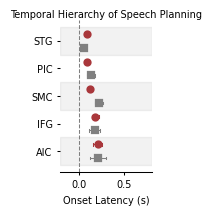

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

roi_order = [
            'STG', 
            'PIC',
            'SMC', 
            'IFG',
            'AIC', 
    ]

# 2. 设置画布风格
fig, ax = plt.subplots(figsize=(3*cm, 5*cm))

# 3. 画核心的点和误差棒 (Pointplot)
# join=False: 不要把点连成线，我们要的是独立的估计值
# dodge=0.5: 让左右脑的点错开，不要重叠
# errwidth & capsize: 调整误差棒的粗细和帽子，模仿参考图风格
ax = sns.pointplot(data=df_model, 
                   x="onset_latency", 
                   y="roi", 
                   hue="hemi",
                   order=roi_order,
                   palette={"L": red, "R": 'gray'}, # 相同颜色
                   join=False,      # 关键：不连线
                   legend=False,
                   dodge=0.5,       # 关键：左右错开
                   markers=["o", "s"], # 左脑圆点，右脑方块，增加区分度
                   scale=0.8,       # 点的大小
                   errorbar=('ci', 95), # 显示 95% 置信区间 (或者用 'se' 显示标准误)
                   capsize=0.1,     # 误差棒的小帽子
                   errwidth=0.75)

# 4. 添加 0ms 参考线 (发声时刻)
# zorder=0 确保线在数据点后面
plt.axvline(0, color='black', linestyle='--', linewidth=0.75, alpha=0.5, zorder=0)

# 5. 添加背景条纹 (可选，像参考图那样的灰白相间)
# 这一步是为了模仿参考图的灰色背景带，增加可读性
for i in range(len(roi_order)):
    if i % 2 == 0: # 偶数行加灰色背景
        plt.axhspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

ax.set_xlim(-0.2, .8)
# 6. 美化调整
plt.xlabel("Onset Latency (s)", fontsize=7)
plt.ylabel("") # ROI 名字已经在 Y 轴刻度上了，不需要 Label
plt.title("Temporal Hierarchy of Speech Planning", fontsize=7, pad=2 )

# 调整图例

# 去掉上方和右侧边框
sns.despine(left=True)

# 调整 Y 轴刻度文字样式

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)
    
# fig.savefig("../img/fig2/fig2_insula_temporal_stimulus.svg", dpi=300, bbox_inches='tight')

In [21]:
import statsmodels.formula.api as smf

target_rois = ['STG',
               'SMC', 
               'IFG',
               'AIC',
               'PIC',
               ] 


df_model = latency[(latency['roi'].isin(target_rois)) & (latency.phase=='response')].copy()

df_model['onset_latency'] = pd.to_numeric(df_model['onset_latency'], errors='coerce')

model = smf.mixedlm("onset_latency ~ roi*hemi", data=df_model, groups=df_model["subject"])

result = model.fit(method=['nm', 'lbfgs'], maxiter=5000)

print(result.summary())

             Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  onset_latency
No. Observations:    923      Method:              REML         
No. Groups:          80       Scale:               0.1594       
Min. group size:     1        Log-Likelihood:      -497.5718    
Max. group size:     58       Converged:           Yes          
Mean group size:     11.5                                       
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept            -0.493    0.044 -11.110 0.000 -0.580 -0.406
roi[T.IFG]            0.022    0.076   0.286 0.775 -0.128  0.171
roi[T.PIC]            0.384    0.060   6.374 0.000  0.266  0.502
roi[T.SMC]           -0.089    0.052  -1.696 0.090 -0.191  0.014
roi[T.STG]            0.315    0.056   5.578 0.000  0.204  0.425
hemi[T.R]             0.100    0.067   

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3682459/379786253.py:23: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(data=df_model_copy,
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3682459/379786253.py:23: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=df_model_copy,


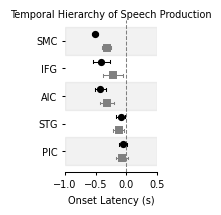

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 设定 ROI 顺序 (建议按照时间先后或者从前到后的解剖位置排序)
roi_order = [
    'SMC',                  # -0.367 (Anticipation/Prediction)
    'IFG',                  #  Baseline (Top-down Processing)
    'AIC',                  # 0.061 (Latest)
    'STG',                  # -0.098 (Auditory Processing)
    'PIC',
]

# 2. 设置画布风格
fig, ax = plt.subplots(figsize=(3*cm, 5*cm))

# 3. 画核心的点和误差棒 (Pointplot)
# join=False: 不要把点连成线，我们要的是独立的估计值
# dodge=0.5: 让左右脑的点错开，不要重叠
# errwidth & capsize: 调整误差棒的粗细和帽子，模仿参考图风格
df_model_copy = df_model.copy()
df_model_copy.onset_latency = df_model_copy.onset_latency + 0.08

ax = sns.pointplot(data=df_model_copy, 
                   x="onset_latency", 
                   y="roi", 
                   hue="hemi",
                   order=roi_order,
                   palette={"L": 'black', "R": 'gray'}, # 相同颜色
                   join=False,      # 关键：不连线
                   legend=False,
                   dodge=0.5,       # 关键：左右错开
                   markers=["o", "s"], # 左脑圆点，右脑方块，增加区分度
                   scale=0.7,       # 点的大小
                   errorbar=('ci', 95), # 显示 95% 置信区间 (或者用 'se' 显示标准误)
                   capsize=0.1,     # 误差棒的小帽子
                   errwidth=0.75)

# 4. 添加 0ms 参考线 (发声时刻)
# zorder=0 确保线在数据点后面
plt.axvline(0, color='black', linestyle='--', linewidth=0.75, alpha=0.5, zorder=0)

# 5. 添加背景条纹 (可选，像参考图那样的灰白相间)
# 这一步是为了模仿参考图的灰色背景带，增加可读性
for i in range(len(roi_order)):
    if i % 2 == 0: # 偶数行加灰色背景
        plt.axhspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

# 6. 美化调整
plt.xlabel("Onset Latency (s)", fontsize=7)
plt.ylabel("") # ROI 名字已经在 Y 轴刻度上了，不需要 Label
plt.title("Temporal Hierarchy of Speech Production", fontsize=7, pad=2 )

# 调整图例
ax.set_xlim(-1, 0.5)
# 去掉上方和右侧边框
sns.despine(left=True)

# 调整 Y 轴刻度文字样式
for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)
    
fig.savefig("../img/fig2/fig2_insula_temporal_response.svg", dpi=300, bbox_inches='tight')

# Maintainance

In [55]:
# Whole-brain maintenance HGA (Delay 0–0.5, mask=True)
# Color/alpha/size all mapped by HGA using the single `reds` colormap
import pyvista as pv
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

# 1) Maintenance mask & aggregation (mean per channel)
maint_mask = (
    # (HGAs['task']=='LexicalDelay') &
    (HGAs['phase'] == 'delay') &
    (HGAs['description'] == 'Repeat') &
    (HGAs['time'] >= 0) &
    (HGAs['time'] <= 0.5) &
    (HGAs['mask'] == True)
)

maint = HGAs[maint_mask]
maint_spatial = (
    maint.groupby('channel')
    .agg({
        'value': 'mean',
        'x': 'first',
        'y': 'first',
        'z': 'first',
        'roi': 'first',
        'label': 'first',
        'phase': 'first',
        'hemi': 'first',
        'subject': 'first',
        'description': 'first',
        'task': 'first'
    })
    .reset_index()
    .rename(columns={'value': 'HGA'})
)

maint_spatial = maint_spatial[~maint_spatial.roi.isin(
    ['Intersection', 'OPC','Cun','CollatAnt',
     'PhG','FuG','LinGs','Hipp','Central','mOccG',
     'LinG','PCuns','PCun','GRect','FuGs','Amyg','Calcarine',
     'Put','OccS','PCun','VDC','LatV','InfLatV','iOccGs',
     'Intersection(unknown)','Thal','BrainStem(unknown)',
     'Paracentral','PCC','Sylvian','OFCs'
     ]
)]

# maint_spatial = maint_spatial[maint_spatial.roi.isin(['AIC'])]
maint_spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0005_LTG14-15,0.716526,-68.886726,-28.295294,0.243498,STG,ctx_lh_G_temp_sup-Lateral,delay,L,D0005,Repeat,SentenceRep
1,D0005_LTG15-16,0.747503,-69.639740,-38.151283,4.609248,STG,ctx_lh_G_temp_sup-Lateral,delay,L,D0005,Repeat,SentenceRep
2,D0005_LTG3-4,0.568635,-61.035833,7.066387,-2.862520,STG,ctx_lh_G_temp_sup-Lateral,delay,L,D0005,Repeat,SentenceRep
3,D0005_LTG4-5,1.273360,-63.895071,-1.988314,1.863490,STG,ctx_lh_G_temp_sup-Lateral,delay,L,D0005,Repeat,SentenceRep
5,D0005_LTG6-7,0.546196,-67.026288,-22.001253,12.457651,SMG,ctx_lh_G_pariet_inf-Supramar,delay,L,D0005,Repeat,SentenceRep


In [56]:
maint_spatial.roi.unique()

array(['STG', 'SMG', 'AIC', 'MFG', 'dACC', 'IFGs', 'SMC', 'ITG', 'IFG',
       'MFGs', 'SFG', 'SFGs', 'SPL', 'AG', 'PIC', 'CGs', 'OFC', 'MTG',
       'ACC', 'STS', 'TP', 'IPL'], dtype=object)

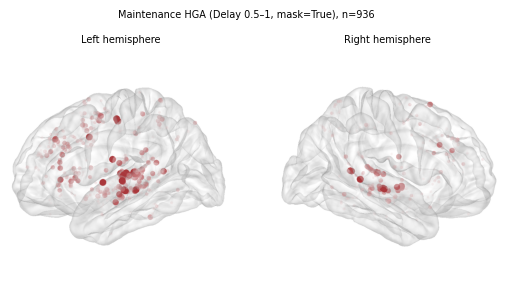

In [58]:

coords = maint_spatial[['x', 'y', 'z']].values
hga_values = maint_spatial['HGA'].values

# 2) Normalization and mapping
vmin, vmax = 0, np.percentile(hga_values, 98)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
alpha_min, alpha_max = 0.1, 1.0
size_min, size_max = 5, 25


def hga_to_size(hga):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)


def hga_to_alpha(hga):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return alpha_min + normalized * (alpha_max - alpha_min)

# 3) Load fsaverage surfaces and KD-trees
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

# 4) Helper to add electrodes (project to pial, map color/alpha/size)
def add_electrodes(brain, coords, hga_vals, tree, pial_coords):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    for pt, hga in zip(coords_proj, hga_vals):
        rgb = reds(norm(hga))[:3]
        alpha = hga_to_alpha(hga)
        size = hga_to_size(hga)
        cloud = pv.PolyData(pt[None, :])
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=rgb,
            opacity=alpha,
            lighting=False,
        )

# 5) Brain setup (both hemispheres, light cortex)
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.3, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.3, size=(800, 800)
)

# 6) Plot all maintenance electrodes (single colormap/alpha/size mapping)
if mask_lh.any():
    add_electrodes(lh_brain, coords[mask_lh], hga_values[mask_lh], lh_tree, lh_pial_coords)
if mask_rh.any():
    add_electrodes(rh_brain, coords[mask_rh], hga_values[mask_rh], rh_tree, rh_pial_coords)

lh_brain.show_view(azimuth=180, elevation=90, distance=350)
rh_brain.show_view(azimuth=0, elevation=90, distance=350)

fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left hemisphere", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right hemisphere", fontsize=fontsize)

plt.suptitle(f"Maintenance HGA (Delay 0.5–1, mask=True), n={len(maint_spatial)}", fontsize=fontsize)
lh_brain.close()
rh_brain.close()

fig.savefig(f'../img/misc/maintenance_hga_first.svg', dpi=300, bbox_inches='tight')

plt.show()

# 2D matrix

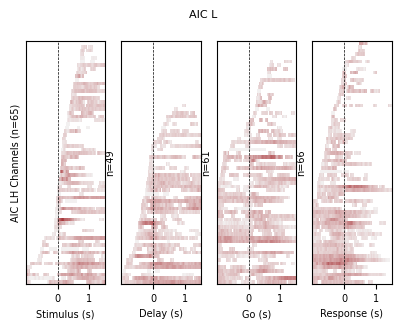

In [47]:
import xarray as xr

roi = 'AIC'
hemi = 'L'
phases = ['stimulus', 'delay', 'go', 'response']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality == 'sound')
    & (HGAs.hemi == hemi)
    & (HGAs.roi == roi)
    & (HGAs.subject != 'D0121')
]

agg_data = subset.groupby(['channel', 'time', 'phase']).agg({
    'value': 'mean',
    'mask': lambda x: x.any()
}).reset_index()

agg_data.loc[~agg_data['mask'], 'value'] = np.nan

max_channels = 0
phase_channel_map = {}
for phase in phases:
    phase_data = agg_data[agg_data.phase == phase]
    sig_channels = phase_data[phase_data['mask'] == True]['channel'].unique()
    first_sig_times = []
    for ch in sig_channels:
        ch_data = phase_data[phase_data.channel == ch]
        sig_times = ch_data[ch_data['mask'] == True]['time'].values
        if len(sig_times) > 0:
            first_sig_times.append((ch, sig_times.min()))
        else:
            first_sig_times.append((ch, np.inf))
    sorted_channels = [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]
    phase_channel_map[phase] = sorted_channels
    max_channels = max(max_channels, len(sorted_channels))

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 8*cm))

for ax, phase in zip(axes, phases):
    sorted_channels = phase_channel_map[phase]
    phase_data = agg_data[agg_data.phase == phase]
    
    if len(sorted_channels) == 0:
        ax.text(0.5, 0.5, 'No significant\nchannels', 
                ha='center', va='center', transform=ax.transAxes, fontsize=7)
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(0, max_channels)
        continue
    
    phase_data_filtered = phase_data[phase_data.channel.isin(sorted_channels)]
    pivot_data = phase_data_filtered.pivot(index='channel', columns='time', values='value')
    pivot_data = pivot_data.reindex(index=sorted_channels)
    
    da = xr.DataArray(
        pivot_data.values,
        coords={'channel': pivot_data.index, 'time': pivot_data.columns},
        dims=['channel', 'time']
    )
    
    time_values = da.coords['time'].values.astype(float)
    if len(time_values) > 1:
        step = np.diff(time_values).mean()
    else:
        step = 0.01  # fallback for single time point
    time_edges = np.concatenate(([time_values[0] - step/2], time_values[:-1] + step/2, [time_values[-1] + step/2]))
    channel_edges = np.arange(len(sorted_channels) + 1)
    
    # Build meshgrid for pcolormesh
    T, C = np.meshgrid(time_edges, channel_edges)
    
    im = ax.pcolormesh(T, C, da.values, cmap=reds, vmin=0, vmax=1.8, shading='auto', rasterized=True)
    
    # fixed ticks at -1, 0, 1
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=7)
    
    ax.set_yticks([])
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, max_channels)
    
    if ax == axes[0]:
        ax.set_ylabel(f'{roi} {hemi}H Channels (n={len(sorted_channels)})', fontsize=7)
    else:
        ax.set_ylabel(f'n={len(sorted_channels)}', fontsize=7)

plt.suptitle(f'{roi} {hemi}', fontsize=8)
plt.savefig(f'../img/fig2/heatmap_{roi}_{hemi}_channels.svg',dpi=300,bbox_inches='tight')
plt.show()

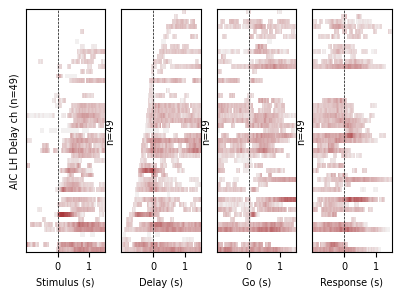

In [48]:
# Delay-electrode view: select channels significant in Delay phase within 0-1s, then plot all phases
# Reuse existing agg_data / parameters

# identify delay-significant channels (time in [0,1])
delay_chs = agg_data[
    (agg_data.phase == 'delay')
    & (agg_data['time'] >= 0)
    & (agg_data['time'] <= 1)
    & (agg_data['mask'] == True)
]['channel'].unique()

# sort delay channels once by first significant time in Delay phase
delay_phase_data = agg_data[agg_data.phase == 'delay']
first_sig_times_delay = []
for ch in delay_chs:
    ch_data = delay_phase_data[delay_phase_data.channel == ch]
    sig_times = ch_data[ch_data['mask'] == True]['time'].values
    if len(sig_times) > 0:
        first_sig_times_delay.append((ch, sig_times.min()))
    else:
        first_sig_times_delay.append((ch, np.inf))
sorted_delay_chs = [ch for ch, _ in sorted(first_sig_times_delay, key=lambda x: x[1])]

max_channels_delay = len(sorted_delay_chs)

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 8*cm))

for ax, phase in zip(axes, phases):
    phase_data = agg_data[agg_data.phase == phase]
    phase_data = phase_data[phase_data.channel.isin(sorted_delay_chs)]
    
    if len(sorted_delay_chs) == 0:
        ax.text(0.5, 0.5, 'No significant\nchannels', 
                ha='center', va='center', transform=ax.transAxes, fontsize=7)
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(0, max_channels_delay)
        continue
    
    # use the fixed delay-based channel order for all phases
    pivot_data = phase_data.pivot(index='channel', columns='time', values='value')
    pivot_data = pivot_data.reindex(index=sorted_delay_chs)
    
    da = xr.DataArray(
        pivot_data.values,
        coords={'channel': pivot_data.index, 'time': pivot_data.columns},
        dims=['channel', 'time']
    )
    
    time_values = da.coords['time'].values.astype(float)
    if len(time_values) > 1:
        step = np.diff(time_values).mean()
    else:
        step = 0.01  # fallback for single time point
    time_edges = np.concatenate(([time_values[0] - step/2], time_values[:-1] + step/2, [time_values[-1] + step/2]))
    channel_edges = np.arange(len(sorted_delay_chs) + 1)
    
    T, C = np.meshgrid(time_edges, channel_edges)
    
    im = ax.pcolormesh(T, C, da.values, cmap=reds, vmin=0, vmax=1.5, shading='auto')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=7)
    
    ax.set_yticks([])
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, max_channels_delay)
    
    if ax == axes[0]:
        ax.set_ylabel(f'{roi} {hemi}H Delay ch (n={len(sorted_delay_chs)})', fontsize=7)
    else:
        ax.set_ylabel(f'n={len(sorted_delay_chs)}', fontsize=7)

plt.show()

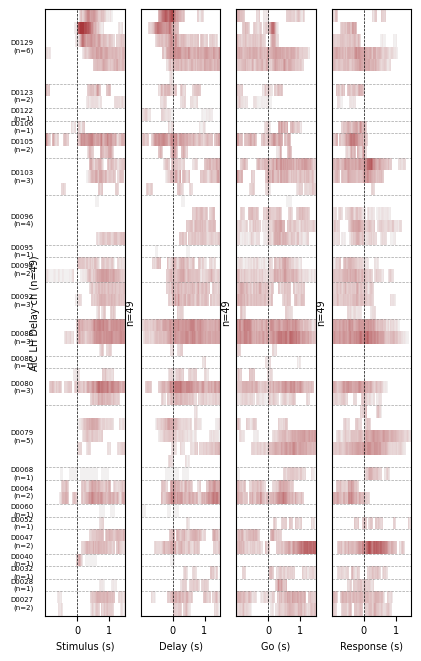

In [51]:
# Subject-grouped Delay electrode heatmap: group by subject, sort within subject by first timepoint value
import xarray as xr
# Modify aggregation to preserve subject information
agg_data_subj = subset.groupby(['channel', 'time', 'phase', 'subject']).agg({
    'value': 'mean',
    'mask': lambda x: x.any()
}).reset_index()

agg_data_subj.loc[~agg_data_subj['mask'], 'value'] = np.nan

# Identify delay-significant channels with subject info
delay_chs_subj = agg_data_subj[
    (agg_data_subj.phase == 'delay')
    & (agg_data_subj['time'] >= 0)
    & (agg_data_subj['time'] <= 1)
    & (agg_data_subj['mask'] == True)
][['channel', 'subject']].drop_duplicates()

# Build unified channel order: group by subject, sort within subject by first timepoint value
sorted_channels_all = []
subject_boundaries = [0]
subjects_sorted = sorted(delay_chs_subj['subject'].unique())

for subj in subjects_sorted:
    subj_chs = delay_chs_subj[delay_chs_subj.subject == subj]['channel'].unique()
    
    # For each phase, get first timepoint value for sorting within this subject
    # We'll use Delay phase for consistency
    delay_phase_data = agg_data_subj[
        (agg_data_subj.phase == 'delay') & 
        (agg_data_subj.subject == subj) &
        (agg_data_subj.channel.isin(subj_chs))
    ]
    
    # Get minimum time point
    min_time = delay_phase_data['time'].min()
    
    # Get value at first timepoint for each channel
    first_time_values = []
    for ch in subj_chs:
        ch_data = delay_phase_data[(delay_phase_data.channel == ch) & (delay_phase_data.time == min_time)]
        if len(ch_data) > 0:
            first_time_values.append((ch, ch_data['value'].values[0]))
        else:
            first_time_values.append((ch, -np.inf))
    
    # Sort channels by first timepoint value (descending)
    sorted_subj_chs = [ch for ch, _ in sorted(first_time_values, key=lambda x: x[1], reverse=True)]
    sorted_channels_all.extend(sorted_subj_chs)
    subject_boundaries.append(len(sorted_channels_all))

max_channels_delay = len(sorted_channels_all)

# Plot all four phases with subject grouping
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 20*cm))

for ax, phase in zip(axes, phases):
    phase_data = agg_data_subj[agg_data_subj.phase == phase]
    phase_data = phase_data[phase_data.channel.isin(sorted_channels_all)]
    
    if len(sorted_channels_all) == 0:
        ax.text(0.5, 0.5, 'No significant\nchannels', 
                ha='center', va='center', transform=ax.transAxes, fontsize=7)
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(0, max_channels_delay)
        continue
    
    # Aggregate by channel and time (average across subjects if needed, though each channel belongs to one subject)
    phase_data_agg = phase_data.groupby(['channel', 'time']).agg({'value': 'mean'}).reset_index()
    
    pivot_data = phase_data_agg.pivot(index='channel', columns='time', values='value')
    pivot_data = pivot_data.reindex(index=sorted_channels_all)
    
    da = xr.DataArray(
        pivot_data.values,
        coords={'channel': pivot_data.index, 'time': pivot_data.columns},
        dims=['channel', 'time']
    )
    
    time_values = da.coords['time'].values.astype(float)
    if len(time_values) > 1:
        step = np.diff(time_values).mean()
    else:
        step = 0.01
    time_edges = np.concatenate(([time_values[0] - step/2], time_values[:-1] + step/2, [time_values[-1] + step/2]))
    channel_edges = np.arange(len(sorted_channels_all) + 1)
    
    T, C = np.meshgrid(time_edges, channel_edges)
    
    im = ax.pcolormesh(T, C, da.values, cmap=reds, vmin=0, vmax=1.5, shading='auto')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=7)
    
    ax.set_yticks([])
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, max_channels_delay)
    
    # Add subject separators (dashed horizontal lines)
    for boundary in subject_boundaries[1:-1]:  # Skip first (0) and last
        ax.axhline(y=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Add subject labels on y-axis (only on first subplot)
    if ax == axes[0]:
        for i, subj in enumerate(subjects_sorted):
            y_mid = (subject_boundaries[i] + subject_boundaries[i+1]) / 2
            n_chs = subject_boundaries[i+1] - subject_boundaries[i]
            ax.text(-0.15, y_mid, f'{subj}\n(n={n_chs})', 
                   transform=ax.get_yaxis_transform(), 
                   fontsize=5, ha='right', va='center')
        ax.set_ylabel(f'{roi} {hemi}H Delay ch (n={len(sorted_channels_all)})', fontsize=7)
    else:
        ax.set_ylabel(f'n={len(sorted_channels_all)}', fontsize=7)


plt.savefig(f'../img/fig2/heatmap_{roi}_{hemi}_channels_subject_grouped.svg',dpi=300,bbox_inches='tight')
plt.show()